filter Heart Rate

In [46]:
import wfdb
import numpy as np
import pandas as pd
from wfdb import processing

record = wfdb.rdrecord("100", pn_dir="mitdb")
signal = record.p_signal[:, 0]
fs = record.fs

# R-peak detection
r_peaks = processing.gqrs_detect(sig=signal, fs=fs)

# RR intervals
rr_intervals = np.diff(r_peaks) / fs

# Heart rate
heart_rate = 60 / rr_intervals

# Time index
rr_times = r_peaks[1:] / fs

hr_series = pd.Series(heart_rate, index=rr_times)

Filtering Outlier

In [47]:
hr_clean = hr_series.copy()

# 1. Physiological filter (giữ lại cho report)
mask_phys = (hr_clean < 40) | (hr_clean > 180)

# 2. Z-score filter (QUAN TRỌNG)
z = (hr_clean - hr_clean.mean()) / hr_clean.std()
mask_z = np.abs(z) > 3

# Combine
mask = mask_phys | mask_z

# Apply
hr_clean[mask] = np.nan

print("Outliers removed:", mask.sum())

Outliers removed: 45


Interpolation

In [48]:
hr_clean = hr_clean.interpolate(method='linear')

In [49]:
# optional: clip nhẹ để giảm extreme nhỏ
hr_clean = hr_clean.clip(lower=50, upper=120)

In [50]:
# hr_clean: đã remove outlier + interpolate
hr_final = hr_clean.dropna()

print("Length:", len(hr_final))

Length: 2271


2. DATA PREPARATION

2.1 Sliding Window

In [51]:
import numpy as np

def create_dataset(series, window_size=5):
    X, y = [], []
    for i in range(len(series) - window_size):
        X.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(X), np.array(y)

window_size = 5
X, y = create_dataset(hr_final.values, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2266, 5)
y shape: (2266,)


2.2 Train/Test Split (time-based)

In [52]:
split = int(len(X) * 0.7)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

2.3 Normalize

In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()

X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

In [54]:
scaler_y = MinMaxScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test = scaler_y.transform(y_test.reshape(-1,1)).flatten()

3. MACHINE LEARNING

3.1. Random Forest

In [55]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

XGBoost

In [56]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

4. DEEP LEARNING (LSTM)

4.1 Reshape

In [57]:
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

4.2 Model LSTM 

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model.fit(
    X_train_lstm, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20


c:\Users\TVPC\Documents\tl kì 2\6-Time Series Analysis and Forecasting\project\Topic-11-ECG-Analysis-with-MIT-BIH-WFDB-\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0610 - val_loss: 0.0119
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0138 - val_loss: 0.0130
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0132 - val_loss: 0.0126
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0134 - val_loss: 0.0120


4.3 Predict

In [59]:
y_pred_lstm = model.predict(X_test_lstm).flatten()

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


5. EVALUATION

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

rmse_rf, mae_rf, r2_rf = evaluate(y_test, y_pred_rf)
rmse_xgb, mae_xgb, r2_xgb = evaluate(y_test, y_pred_xgb)
rmse_lstm, mae_lstm, r2_lstm = evaluate(y_test, y_pred_lstm)

6. MODEL COMPARISON

In [61]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM"],
    "RMSE": [rmse_rf, rmse_xgb, rmse_lstm],
    "MAE": [mae_rf, mae_xgb, mae_lstm],
    "R2": [r2_rf, r2_xgb, r2_lstm]
})

results = results.sort_values(by="RMSE")
print(results)

           Model      RMSE       MAE        R2
1        XGBoost  0.092574  0.063622  0.528257
0  Random Forest  0.093409  0.063054  0.519701
2           LSTM  0.126065  0.100338  0.125179


7. VISUALIZATION

7.1 Forecast Comparison

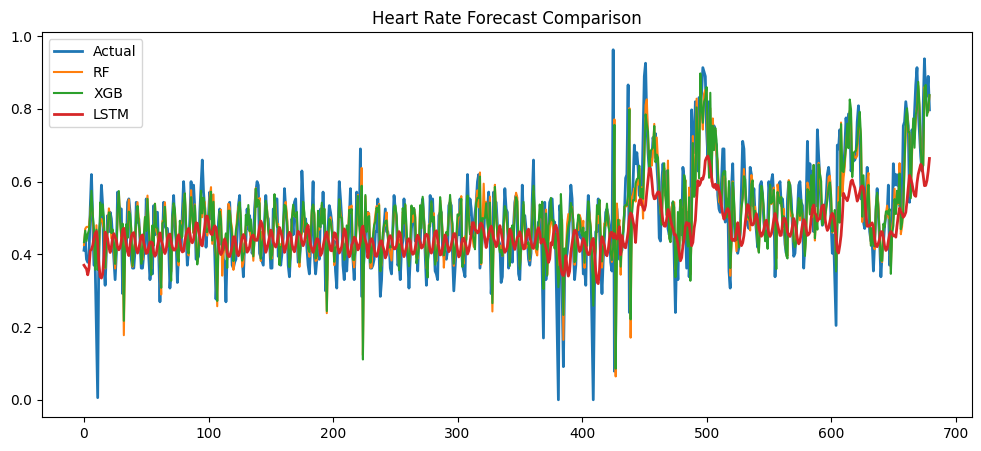

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred_rf, label="RF")
plt.plot(y_pred_xgb, label="XGB")
plt.plot(y_pred_lstm, label="LSTM", linewidth=2)
plt.legend()
plt.title("Heart Rate Forecast Comparison")
plt.show()

7.2 RMSE Bar Chart

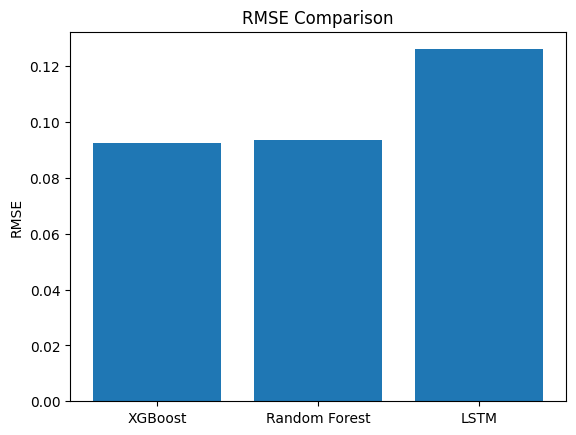

In [63]:
plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

7.3 Zoom Spike

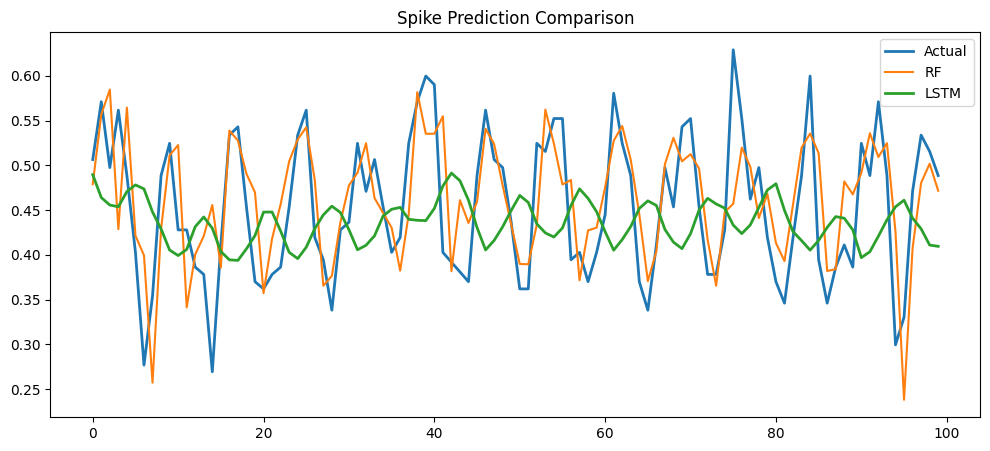

In [64]:
start, end = 100, 200

plt.figure(figsize=(12,5))
plt.plot(y_test[start:end], label="Actual", linewidth=2)
plt.plot(y_pred_rf[start:end], label="RF")
plt.plot(y_pred_lstm[start:end], label="LSTM", linewidth=2)
plt.legend()
plt.title("Spike Prediction Comparison")
plt.show()